# Examples in the paper

Junyan Chu, Shizuo Kaji: Polynomial Interpolation of a Vector Field on a Convex Polygonal Domain, preprint


In [ ]:
#%display latex
from IPython.display import Math, display
from matplotlib import pyplot as plt
import sage.misc.latex as sage_latex
import sys
from tqdm.auto import tqdm
from sage.modules.free_module_element import FreeModuleElement_generic_dense as module_elem
from sage.libs.singular.function_factory import singular_function
syz = singular_function("syz")

sys.path.insert(0, './src')
from hyperplane_arrangements import *

# replace the default show function with one that works better in VSCode
import shutil, sys
try:
    original_show = show
except NameError:
    from IPython.display import Markdown, display
    display(Markdown(
        "## ⚠ Wrong Kernel\n\n"
        + "\n".join(f"- {e}" for e in _err)
        + "\n\n**This notebook must be run with the SageMath kernel, not a plain Python kernel.**\n\n"
        "In JupyterLab: *Kernel → Change Kernel → SageMath*\n\n"
        "In VS Code: click the kernel name in the top-right corner and select *SageMath*."
    ))
    raise SystemExit("Switch to the SageMath kernel and re-run.")
else:
    print(f"OK: SageMath kernel (Python {sys.version.split()[0]})")

def vscode_show(*args, **kwargs):
    for expr in args:
        try:
            if hasattr(expr, '_latex_'):
                display(Math(expr._latex_()))
            else:
                display(Math(sage_latex.latex(expr)))
        except Exception as e:
            print(f"LaTeX rendering failed: {e}")
            original_show(expr, **kwargs)
show = vscode_show
print(sage.version.banner)


SageMath version 10.7, Release Date: 2025-08-09


Basis dimension: 35
3.4143194934442e-30


<IPython.core.display.Math object>

<Axes: >

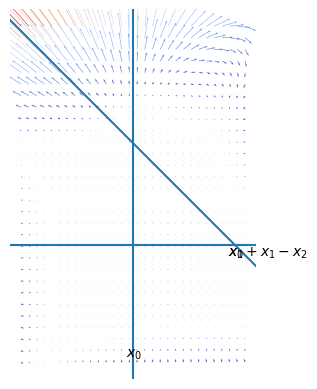

In [2]:
#A=HyperPlaneArr([[1,0,0],[0,1,0],[0,0,1],[1,1,-1],[8,5,-1],[5,-4,0],[4,-5,0]],base_field=QQ)
A=HyperPlaneArr([[1,0,0],[0,1,0],[0,0,1],[1,1,-1]],base_field=QQ)
#P={(1/4,1/2): (1,0),(1/2,1/3): (1/2,1), (1/3, 1/10): (1,0)}
P={(1/4,1/2): (1,0),(1/2,1/3): (1/2,1), (1/3, 1/10): (1,0), (1/6, 1/10): (0,0)} # with a singular point
k0=6
mod_gens=graded_component(A.minimal_generators[1:],k0) # except for Euler
u, err=fit_vf(A,P,mod_gens)
#u, err=equation_k_old(A,Matrix([(1/4,1/2),(1/2,1/3)]),[1,1/2],[0,1],k0)
print(err)
show(u)
A.plot_vfield(u)

In [ ]:
# speed test
k0=10
%time print(len(basis_da(A.mat, k0))) # linear algebraic method
%time print(len(graded_component(A.minimal_generators,k0))) # syzygy is faster

In [ ]:
## red * are the specified singular points
#A.plot_vfield(u,Obs=P,nx=20,ny=20,xlim=(-0.1,2),ylim=(-0.1,2),quiver=False)
A.plot_vfield(u,Obs=P,nx=20,ny=20,xlim=(-0.1,0.7),ylim=(-0.1,0.7),quiver=False)

In [ ]:
# check vectors at sampled points
v1 = A.S.gens()
for p,v in P.items():
    print(p,v,u.subs({v1[i]: p[i] for i in range(A.n-1)} | {v1[A.n-1]:1}))


In [ ]:
# achieve a given error bound
given_min_error(A, P, 0.3)


## divergence free

Note the Hodge decomposition:
dim(G)=dim(DF(G))+dim(RF(G))+dim(HA(G))

In [ ]:
k0=9
mod_gens=graded_component(A.minimal_generators[1:],k0) # except for Euler

G = dehomogenise(A,mod_gens)
G = vector_basis(G) # Remove linear dependency
DFA = divergence_free(G)
print(f'dim(D(A))={len(mod_gens)}, dim((Stheta_E)_k)={binomial(A.n-1+k0-1,k0-1)}, dim(G)={len(G)}, dim DF(G)={len(DFA)}')
#DFA

In [ ]:
# plot some basis elements
nplot=min(3,len(DFA))
fig,axs = plt.subplots(1,nplot,figsize=(5*nplot,5))
for i in range(nplot):
    A.plot_vfield(DFA[i],nx=20,ny=20,xlim=(-0.1,0.7),ylim=(-0.1,0.7),ax=axs[i],quiver=False)

In [ ]:
# check they indeed satisfy nabla.u = 0
[div(u,A.S) for u in DFA[:5]]

In [ ]:
# fitting div-free v.f.
## we can see another vortex at the singular point
u, err=fit_vf(A,P,DFA)
A.plot_vfield(u,Obs=P,nx=20,ny=20,xlim=(-0.1,0.7),ylim=(-0.1,0.7),quiver=False)
u, err


In [ ]:
A=HyperPlaneArr([[1,0,0],[0,1,0],[0,0,1],[1,1,-1]],base_field=QQ)
P={(1/4,1/2): (1,0),(1/2,1/3): (1/2,1), (1/3, 1/10): (1,0), (1/6, 1/10): (0,0)} # data point

mod_gens=graded_component(A.minimal_generators[1:],9) # up to degree 9
G = vector_basis(dehomogenise(A,mod_gens)) # vector basis
DFA = divergence_free(G) # sub-vector space of div-free
print(f'dim(D(A))={len(mod_gens)}, dim DF(G)={len(DFA)}')
u, err=fit_vf(A,P,DFA) # fitting to data point
A.plot_vfield(u,Obs=P,nx=30,ny=30,xlim=(-0.1,1.1),ylim=(-0.1,1.1),quiver=False)

## rotation free

In [ ]:
# we need higher degree
k0=9
mod_gens=graded_component(A.minimal_generators[1:],k0) # except for Euler

G = dehomogenise(A,mod_gens)
G = vector_basis(G) # Remove linear dependency
RFA = rotation_free(G)
print(f'dim(G)={len(G)}, dim RF(G)={len(RFA)}')  # from a dimension counting, we know that we need harmonic flow!


In [ ]:
nplot=min(3,len(RFA))
fig,axs = plt.subplots(1,nplot,figsize=(5*nplot,5))
for i in range(nplot):
    A.plot_vfield(RFA[i],nx=20,ny=20,xlim=(-0.1,0.7),ylim=(-0.1,0.7),ax=axs[i],quiver=False)

In [ ]:
# check they indeed satisfy nabla x u = 0
[rot(u,A.S) for u in RFA]

In [ ]:
# fitting div-free v.f.
u, err=fit_vf(A,P,RFA)
A.plot_vfield(u,Obs=P,nx=20,ny=20,xlim=(-0.1,0.7),ylim=(-0.1,0.7),quiver=False)
err


## harmonic flow

In [ ]:
# we need higher degree
k0=9
mod_gens=graded_component(A.minimal_generators[1:],k0) # except for Euler

G = dehomogenise(A,mod_gens)
G = vector_basis(G) # Remove linear dependency
HA = harmonic(G)
print(f'dim(G)={len(G)}, dim H(G)={len(HA)}')


In [ ]:
nplot=min(3,len(HA))
fig,axs = plt.subplots(1,nplot,figsize=(5*nplot,5))
for i in range(nplot):
    A.plot_vfield(HA[i],nx=20,ny=20,xlim=(-0.1,0.7),ylim=(-0.1,0.7),ax=axs[i],quiver=False)

In [ ]:
# check they indeed satisfy Delta(u) = 0
[laplacian(u,A.S) for u in HA]


In [ ]:
# fitting harmonic
u, err=fit_vf(A,P,HA)
A.plot_vfield(u,Obs=P,nx=50,ny=50,xlim=(-0.1,0.7),ylim=(-0.1,0.7),quiver=False)
err


In [ ]:
# check interpolation
for p,v in P.items():
    print(p,v,u.subs({v1[i]: p[i] for i in range(A.n-1)} | {v1[A.n-1]:1}))


## Figures in the paper

In [ ]:
# usual curve fitting for scalar data
from numpy.polynomial.polynomial import Polynomial

# Example scalar data
x = np.array([1,4.2,5.8,6.1,8.2,10.1])
y = np.array([1.2, 6.8, 8.1, 16.6, 25.3, 15.7])

# Fit a polynomial
p = Polynomial.fit(x, y,6)

# Generate points for plotting the fitted curve
x_fit = np.linspace(0, 10.3, 100)
y_fit = p(x_fit)

# Plot the original data and the fitted curve
plt.scatter(x, y, label='Data')
plt.plot(x_fit, y_fit, label='Fitted Curve', color='red')
plt.xlim(-0.3,10.3)
plt.ylim(-5,35)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()


In [ ]:
# interpolation
N=5
A=HyperPlaneArr([[0,0,1]]+[[0.1*np.cos(2*np.pi*i/N),0.1*np.sin(2*np.pi*i/N),1] for i in range(N)],base_field=QQ)
P={(1/3,0.7): (2,0),(-0.8,0): (-2,4), (-1/3, -0.7): (3,0), (1/4, 1/10): (2,2)} # with a singular point

xlim=(-1.1,1.2)
ylim=(-1.2,1.2)

fig,axs = plt.subplots(1,2,figsize=(10,5))
A.plot_arr(xlim=xlim,ylim=ylim,Obs=P,ax=axs[0],legend=False)

k0=5
mod_gens=basis_da(A.mat, k0)
u, err=fit_vf(A,P,mod_gens)
#u, err=equation_k_old(A,Matrix([(1/4,1/2),(1/2,1/3)]),[1,1/2],[0,1],k0)
A.plot_vfield(u,xlim=xlim,ylim=ylim,Obs=P,ax=axs[1],quiver=False,legend=False)
print("error: ", err)


In [ ]:
# Non-tangent field (an element of Vect(P)) and tangent field
N=5
A=HyperPlaneArr([[0,0,1]]+[[np.cos(2*np.pi*i/N),np.sin(2*np.pi*i/N),1] for i in range(N)],base_field=QQ)
P={(1/3,0.7): (2,0),(-0.5,0): (-1/2,1), (1/3, -1/3): (1,0), (1/6, 1/10): (0,0)} # with a singular point

x=A.S.gens()
non_tangent_v = vector([x[0]^2,x[1]^2,x[2]^3])
xlim=(-1.3,1.4)
ylim=(-1.3,1.3)

mod_gens=basis_da(A.mat, degs[i])
u, err=fit_vf(A,P,mod_gens)

fig,axs = plt.subplots(1,2,figsize=(5*2,5))
A.plot_vfield(non_tangent_v,xlim=xlim,ylim=ylim,quiver=False,legend=False, ax=axs[0])
A.plot_vfield(u,xlim=xlim,ylim=ylim,quiver=False,legend=False, ax=axs[i])


In [ ]:
# pentagon
N=5
A=HyperPlaneArr([[0,0,1]]+[[np.cos(2*np.pi*i/N),np.sin(2*np.pi*i/N),1] for i in range(N)],base_field=QQ)
P={(1/3,0.7): (2,0),(-0.8,0): (-2,4), (-1/3, -0.7): (3,0), (1/4, 1/10): (0,0)} # with a singular point

# xlim=(-1.1,1.2)
# ylim=(-1.2,1.2)
xlim=(-1.5,1.5)
ylim=(-1.5,1.5)

fig,axs = plt.subplots(1,2,figsize=(10,5))
A.plot_arr(xlim=xlim,ylim=ylim,Obs=P,ax=axs[0],legend=False)

k0=5
mod_gens=basis_da(A.mat, k0)
u, err=fit_vf(A,P,mod_gens)
#u, err=equation_k_old(A,Matrix([(1/4,1/2),(1/2,1/3)]),[1,1/2],[0,1],k0)
A.plot_vfield(u,xlim=xlim,ylim=ylim,Obs=P,ax=axs[1],quiver=False,legend=False)
print("error: ", err)


In [ ]:
## add points one by one
N=5
A=HyperPlaneArr([[0,0,1]]+[[np.cos(2*np.pi*i/N),np.sin(2*np.pi*i/N),1] for i in range(N)],base_field=QQ)
P={(1/5,-0.5): (2,-1),(1/3,0.7): (2,0),(-0.8,0): (-2,4),(-1/3, -0.7): (3,0), (1/4, 1/10): (0,0),(1/5,0.5): (0,0)} # with a singular point

xlim=(-1.1,1.2)
ylim=(-1.2,1.2)

fig,axs = plt.subplots(1,1+len(P),figsize=(5*(1+len(P)),5))
A.plot_arr(xlim=xlim,ylim=ylim,Obs=P,ax=axs[0],legend=False)

k0=5
mod_gens=basis_da(A.mat, k0)
for i in range(len(P)):
    P0 = dict(list(P.items())[:(i+1)])
    u, err=fit_vf(A,P0,mod_gens)
    A.plot_vfield(u,xlim=xlim,ylim=ylim,Obs=P0,ax=axs[i+1],quiver=False,legend=False)
    print("error: ", err)


In [ ]:
## increasing degrees
N=5
A=HyperPlaneArr([[0,0,1]]+[[np.cos(2*np.pi*i/N),np.sin(2*np.pi*i/N),1] for i in range(N)],base_field=QQ)
P={(1/3,0.7): (2,0),(-0.5,0): (-1/2,1), (1/3, -1/3): (1,0), (1/6, 1/10): (0,0)} # with a singular point

xlim=(-1.1,1.3)
ylim=(-1.2,1.2)

# deg=4 has a large error but deg=5 is fine.
degs=[4,5]
fig,axs = plt.subplots(1,len(degs),figsize=(5*len(degs),5))
for i in range(len(degs)):
    mod_gens=basis_da(A.mat, degs[i])
    u, err=fit_vf(A,P,mod_gens)
    A.plot_vfield(u,Obs=P,xlim=xlim,ylim=ylim,quiver=False,legend=False, ax=axs[i])
    print(f"k={degs[i]}, error={err}")

In [ ]:
# div-free, rot-free, harmonic
A=HyperPlaneArr([[0, 0, 1], [1, 0, 1], [0, 1, 1], [-1, 2, 2], [0.5, -1, 1]],base_field=QQ)
#A=HyperPlaneArr([[0, 0, 1], [1, 0, 1], [0, 1, 1], [-1, 0, 1], [0.5, -1, 1],[0.6, 1, -1]],base_field=QQ)
P={(-0.3,0.6): (2,0),(-0.7,-0.5): (-1/2,1), (0.5,-0.5): (0,0)} # with a singular point

#A=HyperPlaneArr([[1,0,0],[0,1,0],[0,0,1],[1,1,-1]],base_field=QQ)
#P={(1/4,1/2): (1,0),(1/2,1/3): (1/2,1), (1/3, 1/10): (1,0)}
#P={(1/4,1/2): (1,0),(1/2,1/3): (1/2,1), (1/3, 1/10): (1,0), (1/6, 1/10): (0,0)} # with a singular point

k0=5
mod_gens=basis_da(A.mat, k0)
G = dehomogenise(A,mod_gens)
G = vector_basis(G) # Remove linear dependency

RFA = rotation_free(G)
DFA = divergence_free(G)
HA = harmonic(G)
print(f'dim(D(A))={len(mod_gens)}, dim((Stheta_E)_k)={binomial(A.n-1+k0-1,k0-1)}, dim(D_0)={len(G)}, dim divfree(G)={len(DFA)}, dim rotfree(G)={len(RFA)}, dim harmonic(G)={len(HA)}')

xlim=(-1.1,1.1)
ylim=(-1.2,1.2)

fig,axs = plt.subplots(1,4,figsize=(5*4,5))
u, err=fit_vf(A,P,G)
A.plot_vfield(u,xlim=xlim,ylim=ylim,Obs=P,ax=axs[0],quiver=False,legend=False)
print("error: ", err)

u, err=fit_vf(A,P,DFA)
A.plot_vfield(u, xlim=xlim,ylim=ylim,Obs=P,ax=axs[1],quiver=False,legend=False)
axs[1].set_title("div free")
print("error: ", err)

u, err=fit_vf(A,P,RFA)
A.plot_vfield(u,xlim=xlim,ylim=ylim,Obs=P,ax=axs[2],quiver=False,legend=False)
axs[2].set_title("rot free")
print("error: ", err)

u, err=fit_vf(A,P,HA)
A.plot_vfield(u,xlim=xlim,ylim=ylim,Obs=P,ax=axs[3],quiver=False,legend=False)
axs[3].set_title("harmonic")
print("error: ", err)


In [ ]:
for u in HA:
    show(u,laplacian(u,A.S))
    A.plot_vfield(u,xlim=xlim,ylim=ylim,Obs=P,quiver=False,legend=False)


In [ ]:
s = (2,1,1)
show(HA[0](s)),show(HA[1](s)),show(HA[2](s))
HA[0][0]/HA[1][0]

In [ ]:
# non regular polygon
A=HyperPlaneArr([[0,0,1],[1,0,-1],[0,1,-1],[1,-1,1],[1,2,1]],base_field=QQ)
P={(1/3,0.7): (2,0),(-0.5,0): (-1/2,1), (1/3, -1/3): (1,0), (1/6, 1/10): (0,0)} # with a singular point

xlim=(-1.1,1.2)
ylim=(-1.1,1.1)

k0=4
mod_gens=basis_da(A.mat, k0)
u, err=fit_vf(A,P,mod_gens)
#u, err=equation_k_old(A,Matrix([(1/4,1/2),(1/2,1/3)]),[1,1/2],[0,1],k0)
A.plot_vfield(u,xlim=xlim,ylim=ylim,Obs=P,quiver=False,legend=False)
print("error: ", err)
